# Station Information

* Station name: CUNSEY BECK_DS NEAR SAWREY_E_202303
* Water Quality Data link: https://environment.data.gov.uk/hydrology/station/E01730A

## 0. Import the Relevant Libraries

In [1]:
from pathlib import Path
from urllib import request
import pandas as pd
import numpy as np
import xgboost as xgb
import torch
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

## 1. Import Base Classes and Helper Functions from the Project GitHub and Set Random Seeds

In [2]:
# Import the Base Classes and Helper Functions from the Project GitHub
url = "https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/base_classes_and_helper_functions.py"

file_path = Path("base_classes_and_helper_functions.py")
if not file_path.exists():
    request.urlretrieve(url, file_path)
import base_classes_and_helper_functions as bchf

In [3]:
# Set the random seed for all PRNGs to ensure reproducibility
bchf.set_random_seed()

## 2. Load the Raw Data from the Project GitHub into a Pandas DataFrame

In [4]:
# Create the path to the directory containing the data in the Jupyter notebook environment
data_path = bchf.load_raw_data(url="https://github.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/raw/main/data/processed_data/windermere_inflows_and_outflow/cunsey_beck/CUNSEY%20BECK_DS%20NEAR%20SAWREY_E_202303/CUNSEY%20BECK_DS%20NEAR%20SAWREY_E_202303_preprocessed_data.zip")

# Assign the full filepath for the preprocessed data
parameter_path = "/content" / data_path / "CUNSEY BECK_DS NEAR SAWREY_E_202303_preprocessed_data.csv"

[INFO] data/raw_data directory has been created.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [5]:
# Load the data into a Pandas DataFrame
df_parameters = pd.read_csv(parameter_path)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,dateTime,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
0,2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,False,False,False,False,False,False,False,False
1,2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,False,False,False,False,False,False,False,False
2,2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,False,False,False,False,False,False,False,False
3,2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,False,False,False,False,False,False,False,False
4,2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,False,False,False,False,False,False,False,False


In [6]:
# Investigate the unique value distributions of the DataFrame
bchf.unique_value_counts(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DISTINCT VALUE COUNTS FOR WATER QUALITY PARAMETER DATAFRAME:
Variable         Number of Distinct Value Counts
dateTime                   48417          

ammonium                   1200           

conductivity               7121           

oxygen_conc                1172           

oxygen_perc                8319           

temperature                17118          

turbidity                  6271           

ammonium_impossible             2            

conductivity_impossible             2            

oxygen_conc_impossible             2            

oxygen_perc_impossible             2            

temperature_impossible             2            

turbidity_impossible             2            

ammonium_anomaly             2            

conductivity_anomaly             2            

oxygen_perc_anomaly             2            

turbidity_anomaly             2            

oxygen_conc_anomaly             1            

temperature_anomaly             1            



In [7]:
# Investigate the datatypes and numbers of missing values for each variable
bchf.datatypes_and_missing_values(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
dateTime          , object        ,            0            
ammonium          , float64       ,           1840          
conductivity      , float64       ,            0            
oxygen_conc       , float64       ,            0            
oxygen_perc       , float64       ,            0            
temperature       , float64       ,            0            
turbidity         , float64       ,            0            
ammonium_impossible, bool          ,            0            
conductivity_impossible, bool          ,            0            
oxygen_conc_impossible, bool          ,            0            
oxygen_perc_impossible, bool          ,            0            
temperature_impossible, bool          ,            0            
turbidity_impossible, bool          ,            0            
ammonium_anomaly  , bool          ,            0            


## 3. Reindex the DataFrame and Engineer Additional Features for Time Series Modelling

In [8]:
# Change the data type for the dateTime column to datetime64
df_parameters["dateTime"] = pd.to_datetime(df_parameters["dateTime"], dayfirst=False)

# Set the datetime column as the index
df_parameters.set_index('dateTime', inplace=True)

# Investigate the first 5 rows of the reindexed DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
dateTime,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,False,False,False,False,False,False,False,False
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,False,False,False,False,False,False,False,False
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,False,False,False,False,False,False,False,False
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,False,False,False,False,False,False,False,False
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,False,False,False,False,False,False,False,False


In [9]:
# Numerically encode date and time as features
df_parameters["day_of_year"] = df_parameters.index.dayofyear
df_parameters["day_of_year_sin"] = np.sin(2*np.pi*(df_parameters["day_of_year"]/365))
df_parameters["day_of_year_cos"] = np.cos(2*np.pi*(df_parameters["day_of_year"]/365))

df_parameters["minute_of_day"] = df_parameters.index.hour*60 + df_parameters.index.minute
df_parameters["minute_of_day_sin"] = np.sin(2*np.pi*(df_parameters["minute_of_day"]/1440))
df_parameters["minute_of_day_cos"] = np.cos(2*np.pi*(df_parameters["minute_of_day"]/1440))

# Remove redundant columns
df_parameters.drop(["day_of_year", "minute_of_day"], axis=1, inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly,day_of_year_sin,day_of_year_cos,minute_of_day_sin,minute_of_day_cos
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,...,False,False,False,False,False,False,0.979614,-0.200891,0.500000,-0.866025
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,...,False,False,False,False,False,False,0.979614,-0.200891,0.488621,-0.872496
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,...,False,False,False,False,False,False,0.979614,-0.200891,0.488621,-0.872496
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,...,False,False,False,False,False,False,0.979614,-0.200891,0.484810,-0.874620
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,...,False,False,False,False,False,False,0.979614,-0.200891,0.484810,-0.874620


In [10]:
# Create lagged variables for each feature
variables = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]

for i in np.arange(1, 5):
  for variable in variables:
    df_parameters[f"{variable}_lag{i}"] = df_parameters[variable].shift(periods=i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_lag3,oxygen_perc_lag3,temperature_lag3,turbidity_lag3,ammonium_lag4,conductivity_lag4,oxygen_conc_lag4,oxygen_perc_lag4,temperature_lag4,turbidity_lag4
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,...,11.34,97.46,8.728,1.77,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,...,11.35,97.54,8.728,3.12,NaN,80.6,11.34,97.46,8.728,1.77


In [11]:
# Create moving averages for each water quality variable
moving_average_windows = np.array([6, 12, 24]) # hours
timestep_windows = moving_average_windows * 4 # number of timesteps

# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_ma{i}"] = df_parameters[variable].rolling(window=i, min_periods=1).mean()

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_ma48,oxygen_perc_ma48,temperature_ma48,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,...,11.340000,97.460000,8.72800,1.770000,NaN,80.600000,11.340000,97.460000,8.72800,1.770000
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,...,11.345000,97.500000,8.72800,2.445000,NaN,80.575000,11.345000,97.500000,8.72800,2.445000
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,...,11.343333,97.503333,8.72800,2.236667,NaN,80.583333,11.343333,97.503333,8.72800,2.236667
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,...,11.342500,97.507500,8.72775,2.395000,NaN,80.550000,11.342500,97.507500,8.72775,2.395000
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,...,11.342000,97.496000,8.72760,2.274000,NaN,80.544000,11.342000,97.496000,8.72760,2.274000


In [12]:
# Create seasonal lagged features
seasonality = 96 # 24 hours prior in 15 minute sensor data

target_vars = ["ammonium", "oxygen_conc", "temperature"]

for target in target_vars:
  df_parameters[f"{target}_seasonal_lag{seasonality}"] = df_parameters[target].shift(periods=seasonality)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96,ammonium_seasonal_lag96,oxygen_conc_seasonal_lag96,temperature_seasonal_lag96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,...,1.770000,NaN,80.600000,11.340000,97.460000,8.72800,1.770000,NaN,NaN,NaN
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,...,2.445000,NaN,80.575000,11.345000,97.500000,8.72800,2.445000,NaN,NaN,NaN
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,...,2.236667,NaN,80.583333,11.343333,97.503333,8.72800,2.236667,NaN,NaN,NaN
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,...,2.395000,NaN,80.550000,11.342500,97.507500,8.72775,2.395000,NaN,NaN,NaN
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,...,2.274000,NaN,80.544000,11.342000,97.496000,8.72760,2.274000,NaN,NaN,NaN


In [13]:
# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_imputed_count_{i}"] = (df_parameters[f"{variable}_impossible"] + df_parameters[f"{variable}_anomaly"]).rolling(window=i, min_periods=1).sum()

# Inpect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_imputed_count_48,oxygen_perc_imputed_count_48,temperature_imputed_count_48,turbidity_imputed_count_48,ammonium_imputed_count_96,conductivity_imputed_count_96,oxygen_conc_imputed_count_96,oxygen_perc_imputed_count_96,temperature_imputed_count_96,turbidity_imputed_count_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-13 10:00:26,NaN,80.60,11.34,97.46,8.728,1.77,True,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2023-04-13 10:03:06,NaN,80.55,11.35,97.54,8.728,3.12,True,False,False,False,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2023-04-13 10:03:34,NaN,80.60,11.34,97.51,8.728,1.82,True,False,False,False,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
2023-04-13 10:04:02,NaN,80.45,11.34,97.52,8.727,2.87,True,False,False,False,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
2023-04-13 10:04:30,NaN,80.52,11.34,97.45,8.727,1.79,True,False,False,False,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0


##4. Create Target Variables for Time Series Prediction

In [14]:
# Create the target variables
timesteps = [1, 2, 4, 24, 48, 96]
for target in target_vars:
    for timestep in timesteps:
        df_parameters[f"{target}_target_t_{str(timestep)}"] = df_parameters[target].shift(periods=-timestep)

# Removed NaN rows added after shifting features and targets
df_parameters.dropna(inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_target_t_4,oxygen_conc_target_t_24,oxygen_conc_target_t_48,oxygen_conc_target_t_96,temperature_target_t_1,temperature_target_t_2,temperature_target_t_4,temperature_target_t_24,temperature_target_t_48,temperature_target_t_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-04-28 15:00:26,0.09,83.29,11.92,111.73,12.432,3.950,False,False,False,False,...,11.51,11.96,12.05,11.85,12.681,13.281,12.963,12.611,11.800,13.197
2023-04-28 16:00:26,0.09,83.81,11.92,112.37,12.681,3.920,False,False,False,False,...,11.28,11.88,11.99,12.03,13.281,13.420,12.714,12.793,11.780,12.983
2023-04-28 17:00:26,0.09,84.33,11.94,114.10,13.281,4.080,False,False,False,False,...,11.18,11.90,12.18,12.13,13.420,12.963,12.514,12.790,11.954,12.875
2023-04-28 18:00:26,0.09,84.07,11.80,113.06,13.420,3.980,False,False,False,False,...,11.19,11.69,12.16,12.10,12.963,12.714,12.314,12.783,11.895,12.739
2023-04-28 19:00:26,0.09,84.02,11.51,109.13,12.963,3.895,False,False,False,False,...,11.14,11.59,11.89,11.91,12.714,12.514,11.881,12.801,11.857,12.619


##5. Split Dataset Into Training/Validation/Testing Sets

In [15]:
# Split the DataFrame into training, validation, and testing sets
df_train, df_val, df_test = bchf.train_val_test_split(df_parameters,
                                                      train_size=0.6,
                                                      val_size=0.2,
                                                      test_size=0.2)

# Save DataFrames as copies to enable in-place modifications
df_train, df_val, df_test = df_train.copy(), df_val.copy(), df_test.copy()

In [16]:
# Loop through DataFrames to convert columns to appropriate data types
for df in [df_train, df_val, df_test]:
    # Identify columns containing Boolean or 64 bit floating point data
    bool_cols = df.select_dtypes(include='bool').columns
    float_cols = df.select_dtypes(include='float64').columns
    # Convert data types to int8 or float32 to reduce memory usage and speed up training
    df[bool_cols] = df[bool_cols].astype('int8')
    df[float_cols] = df[float_cols].astype('float32')

In [17]:
# Investigate the datatype and number of missing values for each variable after preparing dataset for modelling
bchf.datatypes_and_missing_values(df_train, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
ammonium          , float32       ,            0            
conductivity      , float32       ,            0            
oxygen_conc       , float32       ,            0            
oxygen_perc       , float32       ,            0            
temperature       , float32       ,            0            
turbidity         , float32       ,            0            
ammonium_impossible, int8          ,            0            
conductivity_impossible, int8          ,            0            
oxygen_conc_impossible, int8          ,            0            
oxygen_perc_impossible, int8          ,            0            
temperature_impossible, int8          ,            0            
turbidity_impossible, int8          ,            0            
ammonium_anomaly  , int8          ,            0            
conductivity_anomaly, int8          ,            0           

##6. Prepare Data for Forecasting Using Time-Lagged XGBoost

In [18]:
# Create list of target variables
targets = []
for target in target_vars:
    for timestep in timesteps:
        targets.append(f"{target}_target_t_{timestep}")

# Create list of features
features = df_train.columns.drop(targets)

print("Targets:", targets)
print("\nFeatures:", features)

Targets: ['ammonium_target_t_1', 'ammonium_target_t_2', 'ammonium_target_t_4', 'ammonium_target_t_24', 'ammonium_target_t_48', 'ammonium_target_t_96', 'oxygen_conc_target_t_1', 'oxygen_conc_target_t_2', 'oxygen_conc_target_t_4', 'oxygen_conc_target_t_24', 'oxygen_conc_target_t_48', 'oxygen_conc_target_t_96', 'temperature_target_t_1', 'temperature_target_t_2', 'temperature_target_t_4', 'temperature_target_t_24', 'temperature_target_t_48', 'temperature_target_t_96']

Features: Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_impossible', 'conductivity_impossible',
       'oxygen_conc_impossible', 'oxygen_perc_impossible',
       'temperature_impossible', 'turbidity_impossible', 'ammonium_anomaly',
       'conductivity_anomaly', 'oxygen_perc_anomaly', 'turbidity_anomaly',
       'oxygen_conc_anomaly', 'temperature_anomaly', 'day_of_year_sin',
       'day_of_year_cos', 'minute_of_day_sin', 'minute_of_day_cos',
       'ammonium_la

In [19]:
# Create array for training features
X_train = df_train[features].values
# Create training targets dictionary
y_train_dict = {}
# Populate training targets dictionary with training data
for target in targets:
    y_train_dict[target] = df_train[target].values

# Create array for validation features
X_val = df_val[features].values
# Create validation targets dictionary
y_val_dict = {}
# Populate validation targets dictionary with validation data
for target in targets:
    y_val_dict[target] = df_val[target].values

# Create array for testing features
X_test = df_test[features].values
# Create testing targets dictionary
y_test_dict = {}
# Populate testing targets dictionary with testing data
for target in targets:
    y_test_dict[target] = df_test[target].values

In [20]:
# Create dictionary containing DMatrices for training, validating, and testing XGBoost on each target variable
dmatrices_train_dict = {}
dmatrices_val_dict = {}
dmatrices_test_dict = {}

# Store training DMatrices in dictionary for each target variable
for target in targets:
    # Create training DMatrices and store in dictionary
    dmatrices_train_dict[target] = xgb.DMatrix(X_train, label=y_train_dict[target])
    # Create validation DMatrices and store in dictionary
    dmatrices_val_dict[target] = xgb.DMatrix(X_val, label=y_val_dict[target])
    # Create testing DMatrices and store in dictionary
    dmatrices_test_dict[target] = xgb.DMatrix(X_test, label=y_test_dict[target])

##7. Optimise XGBoost Hyperparameters Using Random Search

In [21]:
# Create a function that creates a random dictionary of hyperparameter configurations
def random_sample_hparams_xgboost():
    """
    Creates a random dictionary of hyperparameters for the XGBoost algorithm
    that can be used for exploring hyperparameter configuration ranges using
    HPO methods such as random search.

    Args:
      - None.

    Returns:
      hparams (dict): A random dictionary of hyperparameters.

    Side effects:
      - None.
    """
    # Create a random dictionary of hyperparameters from predefined configuration ranges (early experiments determined search space)
    hparams = {
        "objective": "reg:squarederror", # training objective to be minimised (regression based on squared error)
        "eval_metric": "rmse", # evaluation metric minimise during training (root mean squared error as XGBoost does not directly support mean squared error)
        "tree_method": "hist", # algorithm used for constructing trees in XGBoost (histogram approimated greedy algorithm for faster training)
        "device": "cuda" if torch.cuda.is_available() else "cpu", # device used for computation (uses GPU acceleration if available or defaults to CPU if not)
        "eta": 10**np.random.uniform(-3.5, -1.5), # learning rate (explores a lognormal distribution between (approximately) 0.0003 and 0.03 where smaller values result in slower training but more stable convergence)
        "gamma": np.random.uniform(3, 5), # minimum loss reduction required to split a node (explores a uniform distribution between 3 and 5 where larger values can reduce overfitting)
        "max_depth": np.random.randint(3, 10), # maximum tree depth (explores a discrete uniform distribution between 3 and 9 where larger trees can capture more complex patterns but risk overfitting)
        "min_child_weight": np.random.randint(4, 9), # minimum sum of Hessians (second order loss derivatives) required in a child node to allow a split (explores a discrete uniform distribution between 4 and 8 where lower values allow more aggressive splitting that may increase both model complexity and overfitting risk)
        "subsample": np.random.uniform(0.5, 0.7), # proportion of training dataset to subsample per boosting iteration prior to growing new trees (explores a uniform distribution between 30% and 70% where smaller proportion can introduce randomness that reduces overfitting whilst larger samples can retain more information that helps capture rare events)
        "colsample_bytree": np.random.uniform(0.5, 0.7), # proportion of columns (features) sampled by each tree (explores a uniform distribution between 30% and 70% where smaller values can prevent overfitting whilst larger values can capture more complex interdepencies between features and targets)
        "lambda": 10**np.random.uniform(1, 3), # L2 regularisation term applied to weights (explores a lognormal distribution between 1 and 1000 where larger values can reduce model complexity and overfitting)
        "alpha": 10**np.random.uniform(1, 3) # L1 regularisation term applied to weights (explores a lognormal distribution between 1 and 1000 where larger values can reduce model complexity and overfitting)
        }

    # Return the random dictionary of hyperparameters
    return hparams

In [22]:
# Generate 30 random hyperparameter configurations
bchf.set_random_seed()
random_hparam_configs = []
for i in np.arange(0,30):
    random_hparam_configs.append(random_sample_hparams_xgboost())

In [23]:
# Create the list of targets that will be used for HPO
hpo_targets = ["ammonium_target_t_96", "oxygen_conc_target_t_96", "temperature_target_t_96"] # use longest forecast horizon for HPO as this is the most complex model

# Create empty dictionaries for holding the best alpha configuration and best validation mse
best_hparam_dict = {}
best_val_rmse_dict = {}

# Specify the maximum number of trees/boosting rounds for training XGBoost
NUM_BOOST_ROUND = 10000 # set to 10000 to allow high ceiling for model complexity when early stopping is also used to prevent overfitting and excessive resource use
EARLY_STOPPING_ROUNDS = 50 # set to 50 to stop training after 50 rounds with no validation improvement

In [24]:
# Loop through HPO targets and store best hyperparameters and configurations and validation errors
for target in hpo_targets:
    print("\n----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print(f"NOW PREDICTING {target}".upper())
    best_rmse_val = float("inf") # initialise as infinity to ensure replaced by first evaluated trial
    best_hparam_config = None # initialise as none to ensure replaced by first evaluated trial
    # Initialise a counter to track trial number
    trial_counter = 1
    # Loop through random hyperparameter configurations
    for config in random_hparam_configs:
        # Print the current hyperparameter configuration for tracking verbose evaluation
        print("----------------------------------------------------------")
        print(f"\nTRIAL NUMBER {str(trial_counter)} WITH HYPERPARAMETER CONFIGURATION: {config}")
        # Specify the data to be used for training and evaluation of the model
        evallist = [
            (dmatrices_train_dict[target], "training"),
             (dmatrices_val_dict[target], "validation")
             ]
        # Train the XGBoost model on the data using the current hyperparameter configuration
        xgboost_model = xgb.train(
            config, # use current hyperparameters
            dmatrices_train_dict[target], # use the dmatrix corresponding to the current target for training
            num_boost_round=NUM_BOOST_ROUND, # maximum number of trees/boosting rounds to train for (defaults to 1000 to allow high ceiling for model complexity when early stopping is also used)
            early_stopping_rounds=EARLY_STOPPING_ROUNDS, # number of rounds with no validation improvement to allow before stopping training (defaults to 10 to speed up training and prevent overfitting)
            evals=evallist, # maps to the data used for evaluation
            verbose_eval=EARLY_STOPPING_ROUNDS*6 # number of rounds after which to print performance
            )
        # Create predictions using validation data
        y_val_pred = xgboost_model.predict(dmatrices_val_dict[target])
        # Compute the root mean squared error on the validation data
        rmse_val = root_mean_squared_error(y_val_dict[target], y_val_pred)
        # Store the configuration and error in dictionaries if lower validation error than previous trials
        if rmse_val < best_rmse_val:
            best_rmse_val = rmse_val
            best_hparam_config = config
        # Add to the counter to track trials
        trial_counter += 1
    # Store the best hyperparameter configuration and root mean squared validation error in dictionaries for each target
    best_hparam_dict[target] = best_hparam_config
    best_val_rmse_dict[target] = best_rmse_val


----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW PREDICTING AMMONIUM_TARGET_T_96
----------------------------------------------------------

TRIAL NUMBER 1 WITH HYPERPARAMETER CONFIGURATION: {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'eta': 0.026304775926427458, 'gamma': 4.399024099899152, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.5440134599565704, 'colsample_bytree': 0.5722112707928115, 'lambda': 301.7741118446677, 'alpha': 983.8104927455976}
[0]	training-rmse:0.56272	validation-rmse:0.41041
[240]	training-rmse:0.55339	validation-rmse:0.40735
----------------------------------------------------------

TRIAL NUMBER 2 WITH HYPERPARAMETER CONFIGURATION: {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'eta': 0.001357356589364

In [25]:
# Print HPO results
print(f"The best hyperparameter configuration for ammonium predictions was {best_hparam_dict["ammonium_target_t_96"]} with mean squared validation error {best_val_rmse_dict["ammonium_target_t_96"]}")
print(f"The best hyperparameter configuration for dissolved oxygen predictions was {best_hparam_dict["oxygen_conc_target_t_96"]} with mean squared validation error {best_val_rmse_dict["oxygen_conc_target_t_96"]}")
print(f"The best hyperparameter configuration for temperature predictions was {best_hparam_dict["temperature_target_t_96"]} with mean squared validation error {best_val_rmse_dict["temperature_target_t_96"]}")

The best hyperparameter configuration for ammonium predictions was {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'eta': 0.0004326843778069658, 'gamma': 4.248471147584494, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.568636302410444, 'colsample_bytree': 0.620554013618193, 'lambda': 544.0268037762216, 'alpha': 715.9996767727415} with mean squared validation error 0.40602853894233704
The best hyperparameter configuration for dissolved oxygen predictions was {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'eta': 0.0004966803387414822, 'gamma': 3.2473775008047014, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.5951316822869007, 'colsample_bytree': 0.6404578126347855, 'lambda': 16.01495005828387, 'alpha': 15.32337067923462} with mean squared validation error 0.5585165023803711
The best hyperparameter configuration for temperature predictions was {'objective': 'reg:squarederro

##8. Fit the XGBoost Models to Training Data

In [26]:
# Create a dictionary to hold XGBoost models
xgboost_model_dict = {}

# Create a mapping of each water quality variable name to the optimised hyperparameter config
hpo_target_mapping = {
    "ammonium": best_hparam_dict["ammonium_target_t_96"],
    "oxygen": best_hparam_dict["oxygen_conc_target_t_96"],
    "temperature": best_hparam_dict["temperature_target_t_96"]}

In [27]:
# Train the XGBoost models for each water quality variable and forecast horizon
for target in targets:
    print("\n----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print(f"NOW TRAINING TO PREDICT {target}".upper())
    # Obtain the name of the target water quality variable by splitting string on underscores
    var_name = target.split("_")[0] # returns "ammonium", "oxygen", or "temperature"
    # Specify the data to be used for training and evaluating the model
    evallist_target = [
        (dmatrices_train_dict[target], "training"),
        (dmatrices_val_dict[target], "validation")
    ]
    # Train the XGBoost model with the optimised hyperparameters for each target variable
    xgb_model = xgb.train(
        hpo_target_mapping[var_name], # use optimised hyperparameters that correspond to the correct target variable
        dmatrices_train_dict[target], # use the correct dmatrix for each target
        num_boost_round=NUM_BOOST_ROUND*10,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        evals=evallist_target, # maps to the data to be used for evaluation
        verbose_eval=EARLY_STOPPING_ROUNDS
        )
    # Add the trained XGBoost model to the dictionary of models
    xgboost_model_dict[target] = xgb_model


----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW TRAINING TO PREDICT AMMONIUM_TARGET_T_1
[0]	training-rmse:0.56299	validation-rmse:0.41077
[50]	training-rmse:0.56095	validation-rmse:0.40979
[100]	training-rmse:0.55894	validation-rmse:0.40884
[150]	training-rmse:0.55696	validation-rmse:0.40790
[200]	training-rmse:0.55498	validation-rmse:0.40698
[250]	training-rmse:0.55304	validation-rmse:0.40607
[300]	training-rmse:0.55118	validation-rmse:0.40517
[350]	training-rmse:0.54933	validation-rmse:0.40430
[400]	training-rmse:0.54751	validation-rmse:0.40343
[450]	training-rmse:0.54570	validation-rmse:0.40257
[500]	training-rmse:0.54394	validation-rmse:0.40173
[550]	training-rmse:0.54223	validation-rmse:0.40090
[600]	training-rmse:0.54053	validation-rmse:0.40008
[650]	training-rmse:0.53890	validation-rmse:0.39929
[700]	training-rmse:0.53729	validat

## 9. Generate Predictions and Evaluate Performance

In [28]:
# Create a dictionary containing training predictions
y_pred_train_dict = {}
for target in targets:
    y_pred_train_dict[target] = xgboost_model_dict[target].predict(dmatrices_train_dict[target])

# Create a dictionary containing validation predictions
y_pred_val_dict = {}
for target in targets:
    y_pred_val_dict[target] = xgboost_model_dict[target].predict(dmatrices_val_dict[target])

# Create a dictionary containing testing predictions
y_pred_test_dict = {}
for target in targets:
    y_pred_test_dict[target] = xgboost_model_dict[target].predict(dmatrices_test_dict[target])

In [29]:
# Evaluate predictions against targets for each water quality variable and forecast horizon on training, validation, and testing sets
for target in targets:
    print(f"\nTRAINING PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_train_dict[target],
                                           y_pred=y_pred_train_dict[target]))
    print(f"VALIDATION PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_val_dict[target],
                                           y_pred=y_pred_val_dict[target]))
    print(f"TEST PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_test_dict[target],
                                           y_pred=y_pred_test_dict[target]))
    print("---------------------------------------------------------------")


TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.16823044419288635, 'RMSE': 0.41015905141830444, 'MAE': 0.10038082301616669, 'r^2': 0.46931397914886475, 'NSE': np.float32(0.46931398)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.11031349748373032, 'RMSE': 0.33213475346565247, 'MAE': 0.04994623735547066, 'r^2': 0.34373974800109863, 'NSE': np.float32(0.34373975)}
TEST PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.0013625103747472167, 'RMSE': 0.03691219910979271, 'MAE': 0.027958661317825317, 'r^2': 0.8086769580841064, 'NSE': np.float32(0.80867696)}
---------------------------------------------------------------

TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.17025287449359894, 'RMSE': 0.41261711716651917, 'MAE': 0.10127589106559753, 'r^2': 0.4629359841346741, 'NSE': np.float32(0.46293598)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.1122262105345726, 'RMSE': 0.33500179648399353, 'MAE': 0.05051931366324425, 'r^2': 0.33233940601348877, 'NSE': np.

##10. Plot XGBoost Model Predictions Against Observations

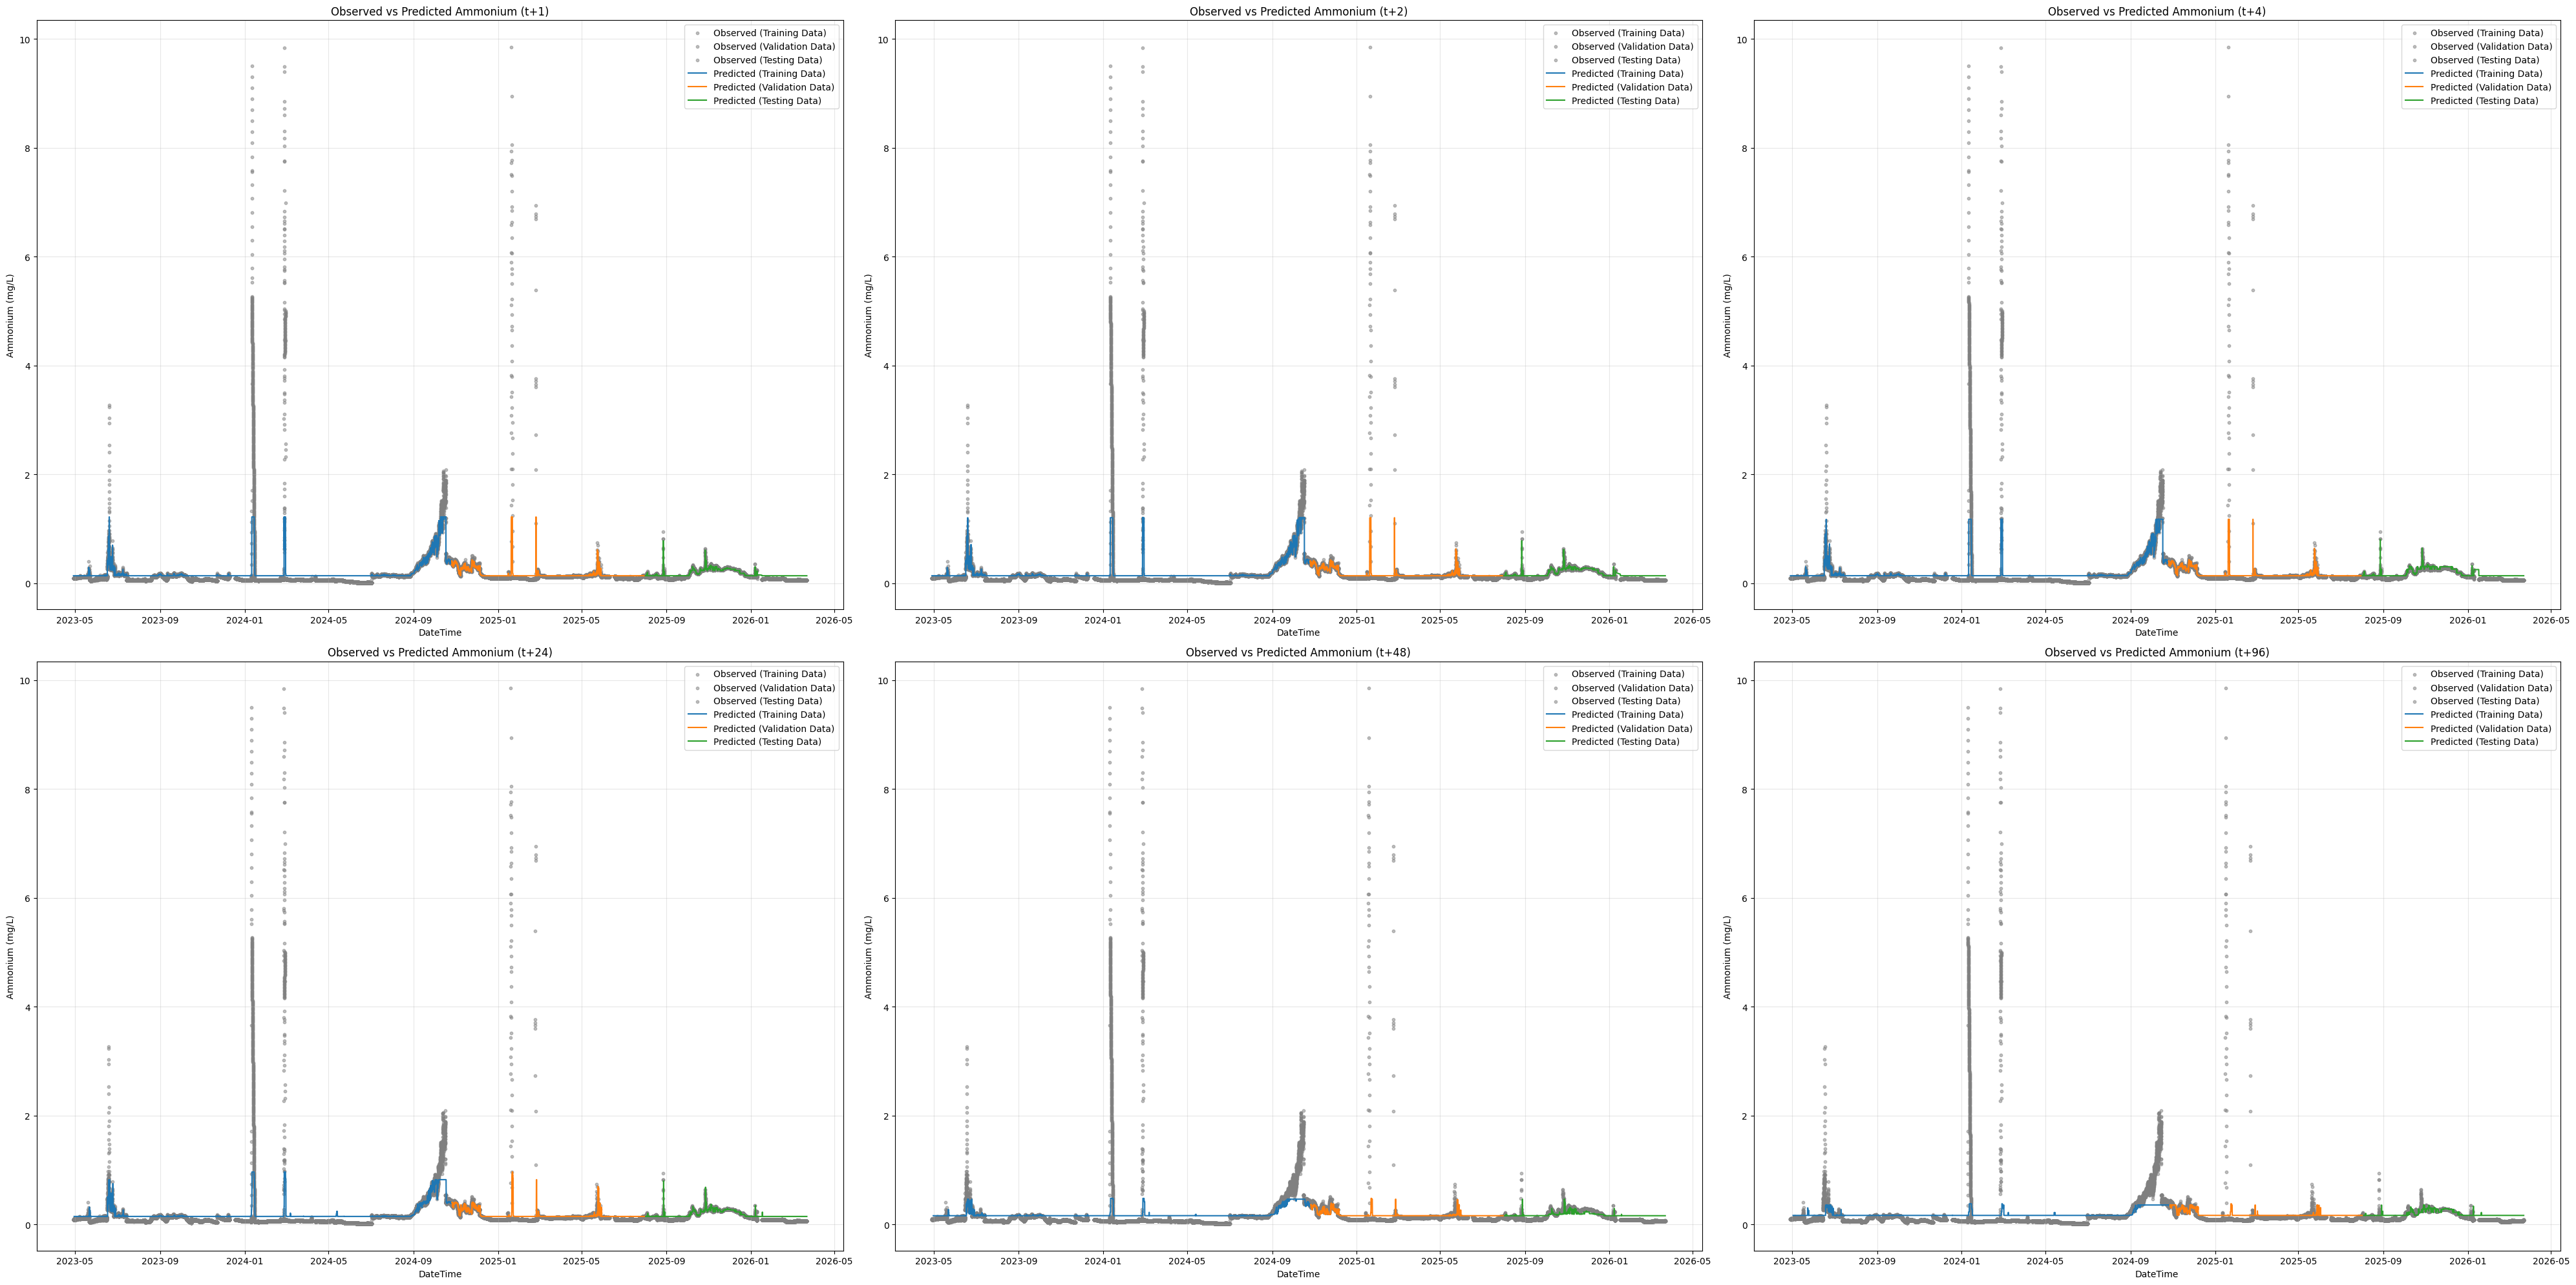

In [30]:
# Create a list of ammonium_targets
NUM_VARIABLES = 3 # 3 target variables: ammonium, dissolved oxygen, and temperature
ammonium_targets = targets[:int(len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(ammonium_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(ammonium_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Ammonium (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Ammonium (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

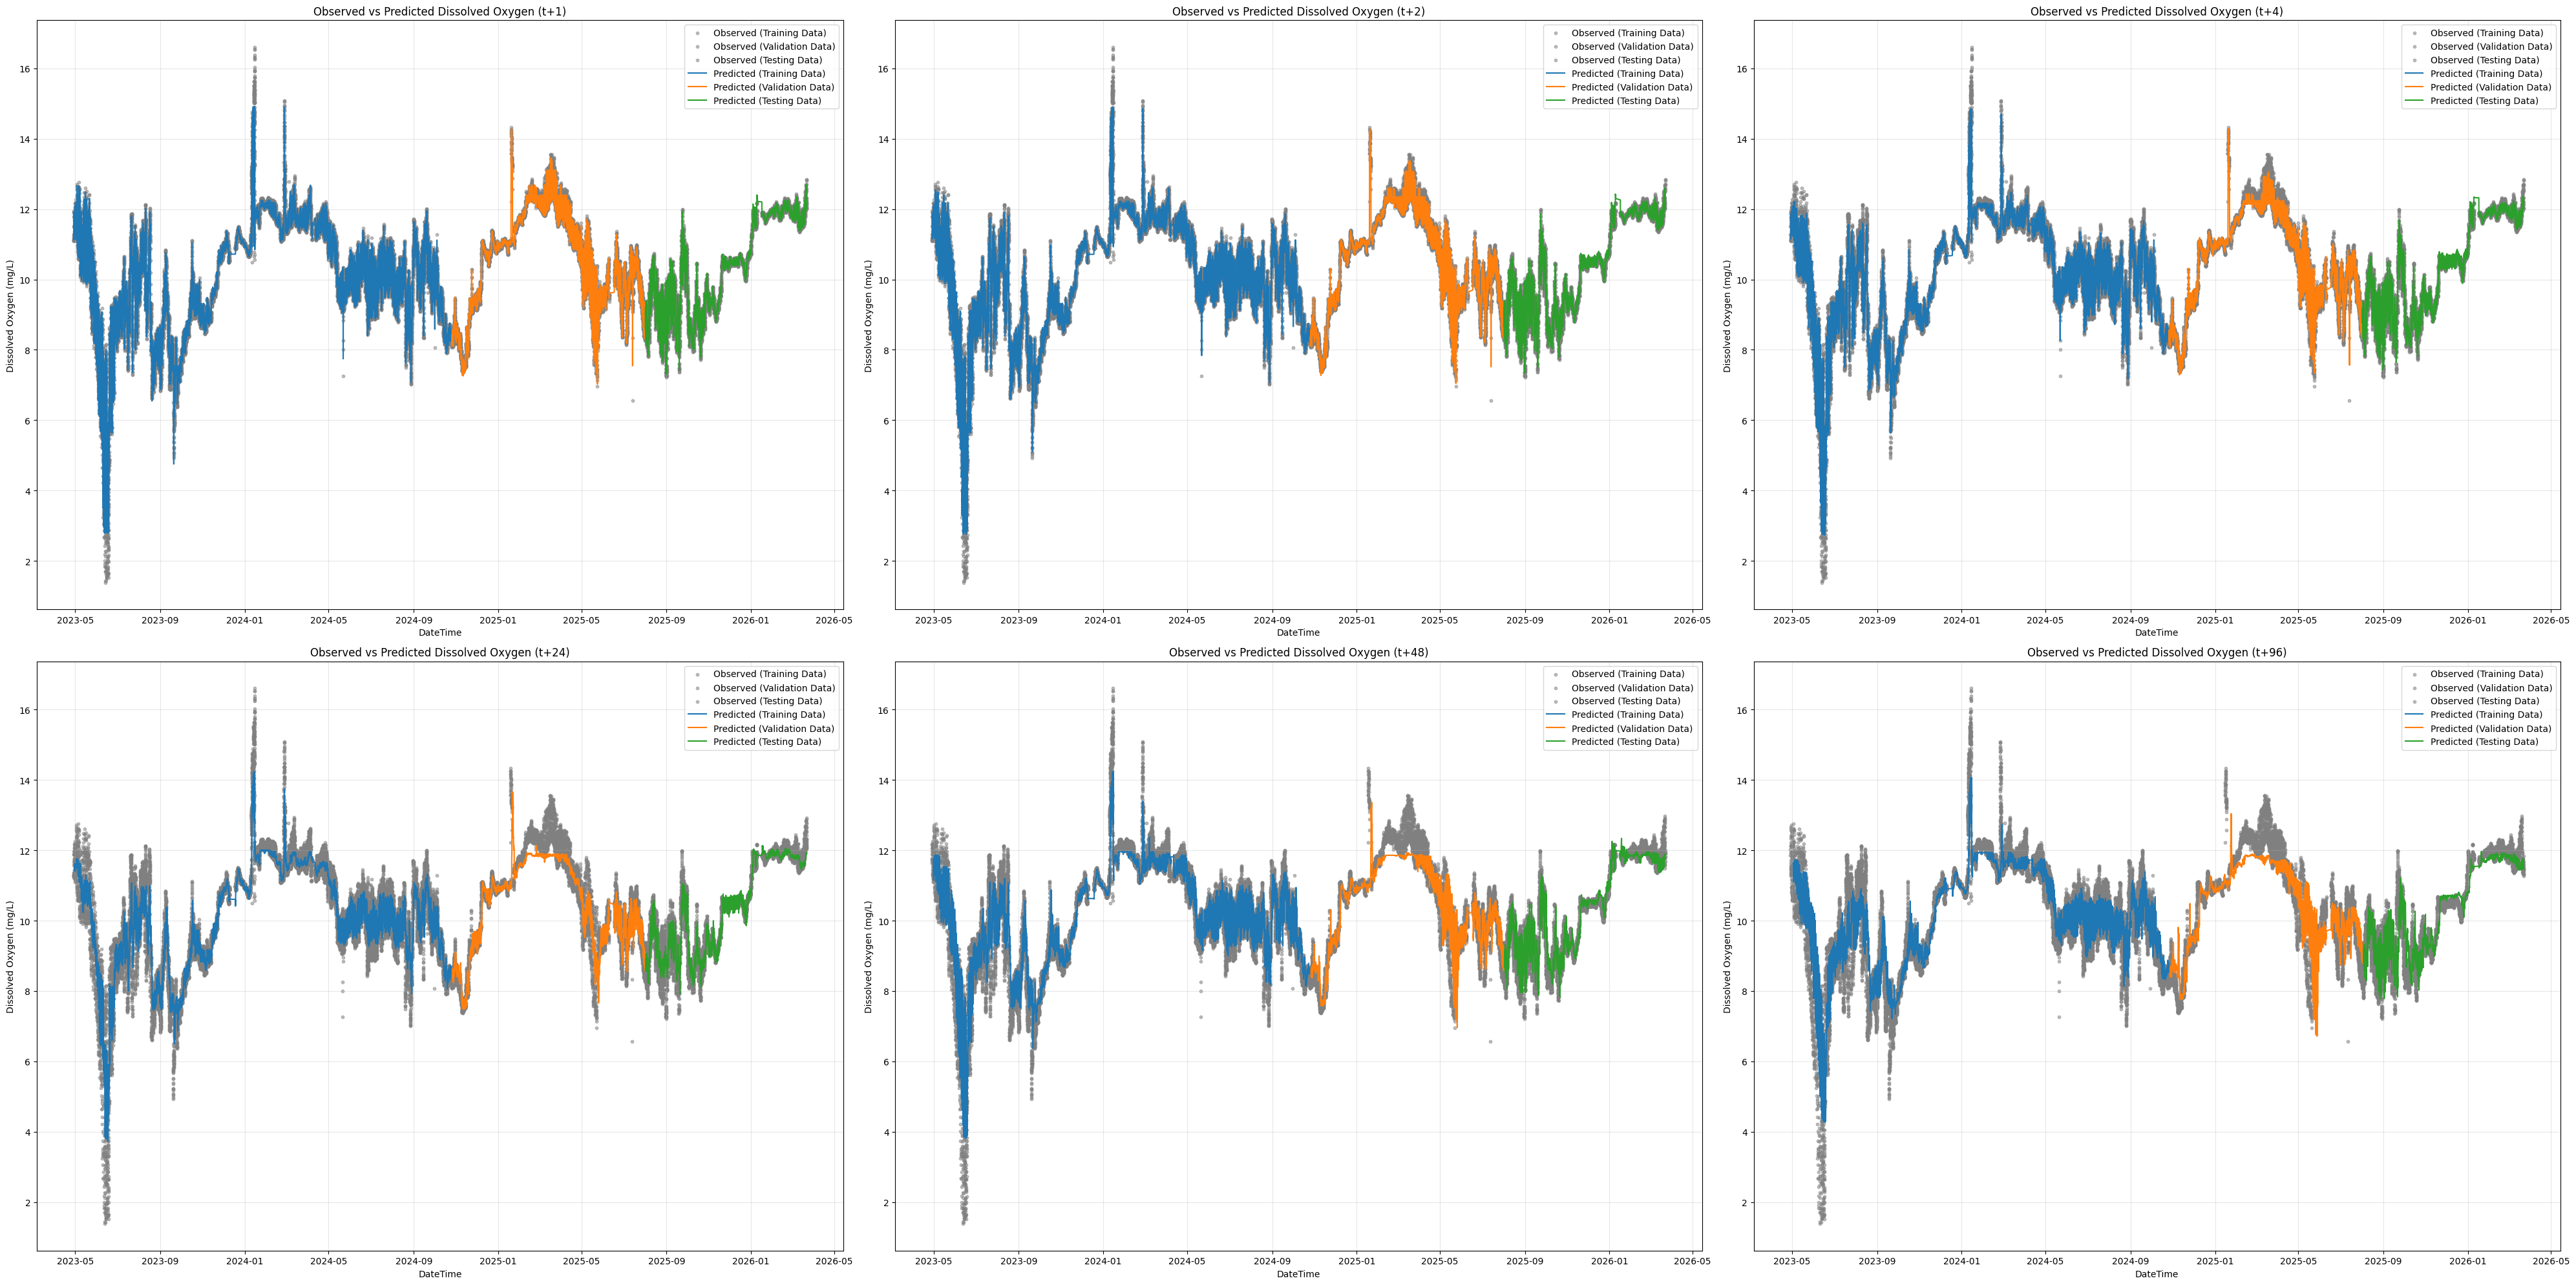

In [31]:
# Create a list of dissolved oxygen targets
oxygen_targets = targets[int(len(targets)/3):int(2*len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(oxygen_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(oxygen_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Dissolved Oxygen (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Dissolved Oxygen (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

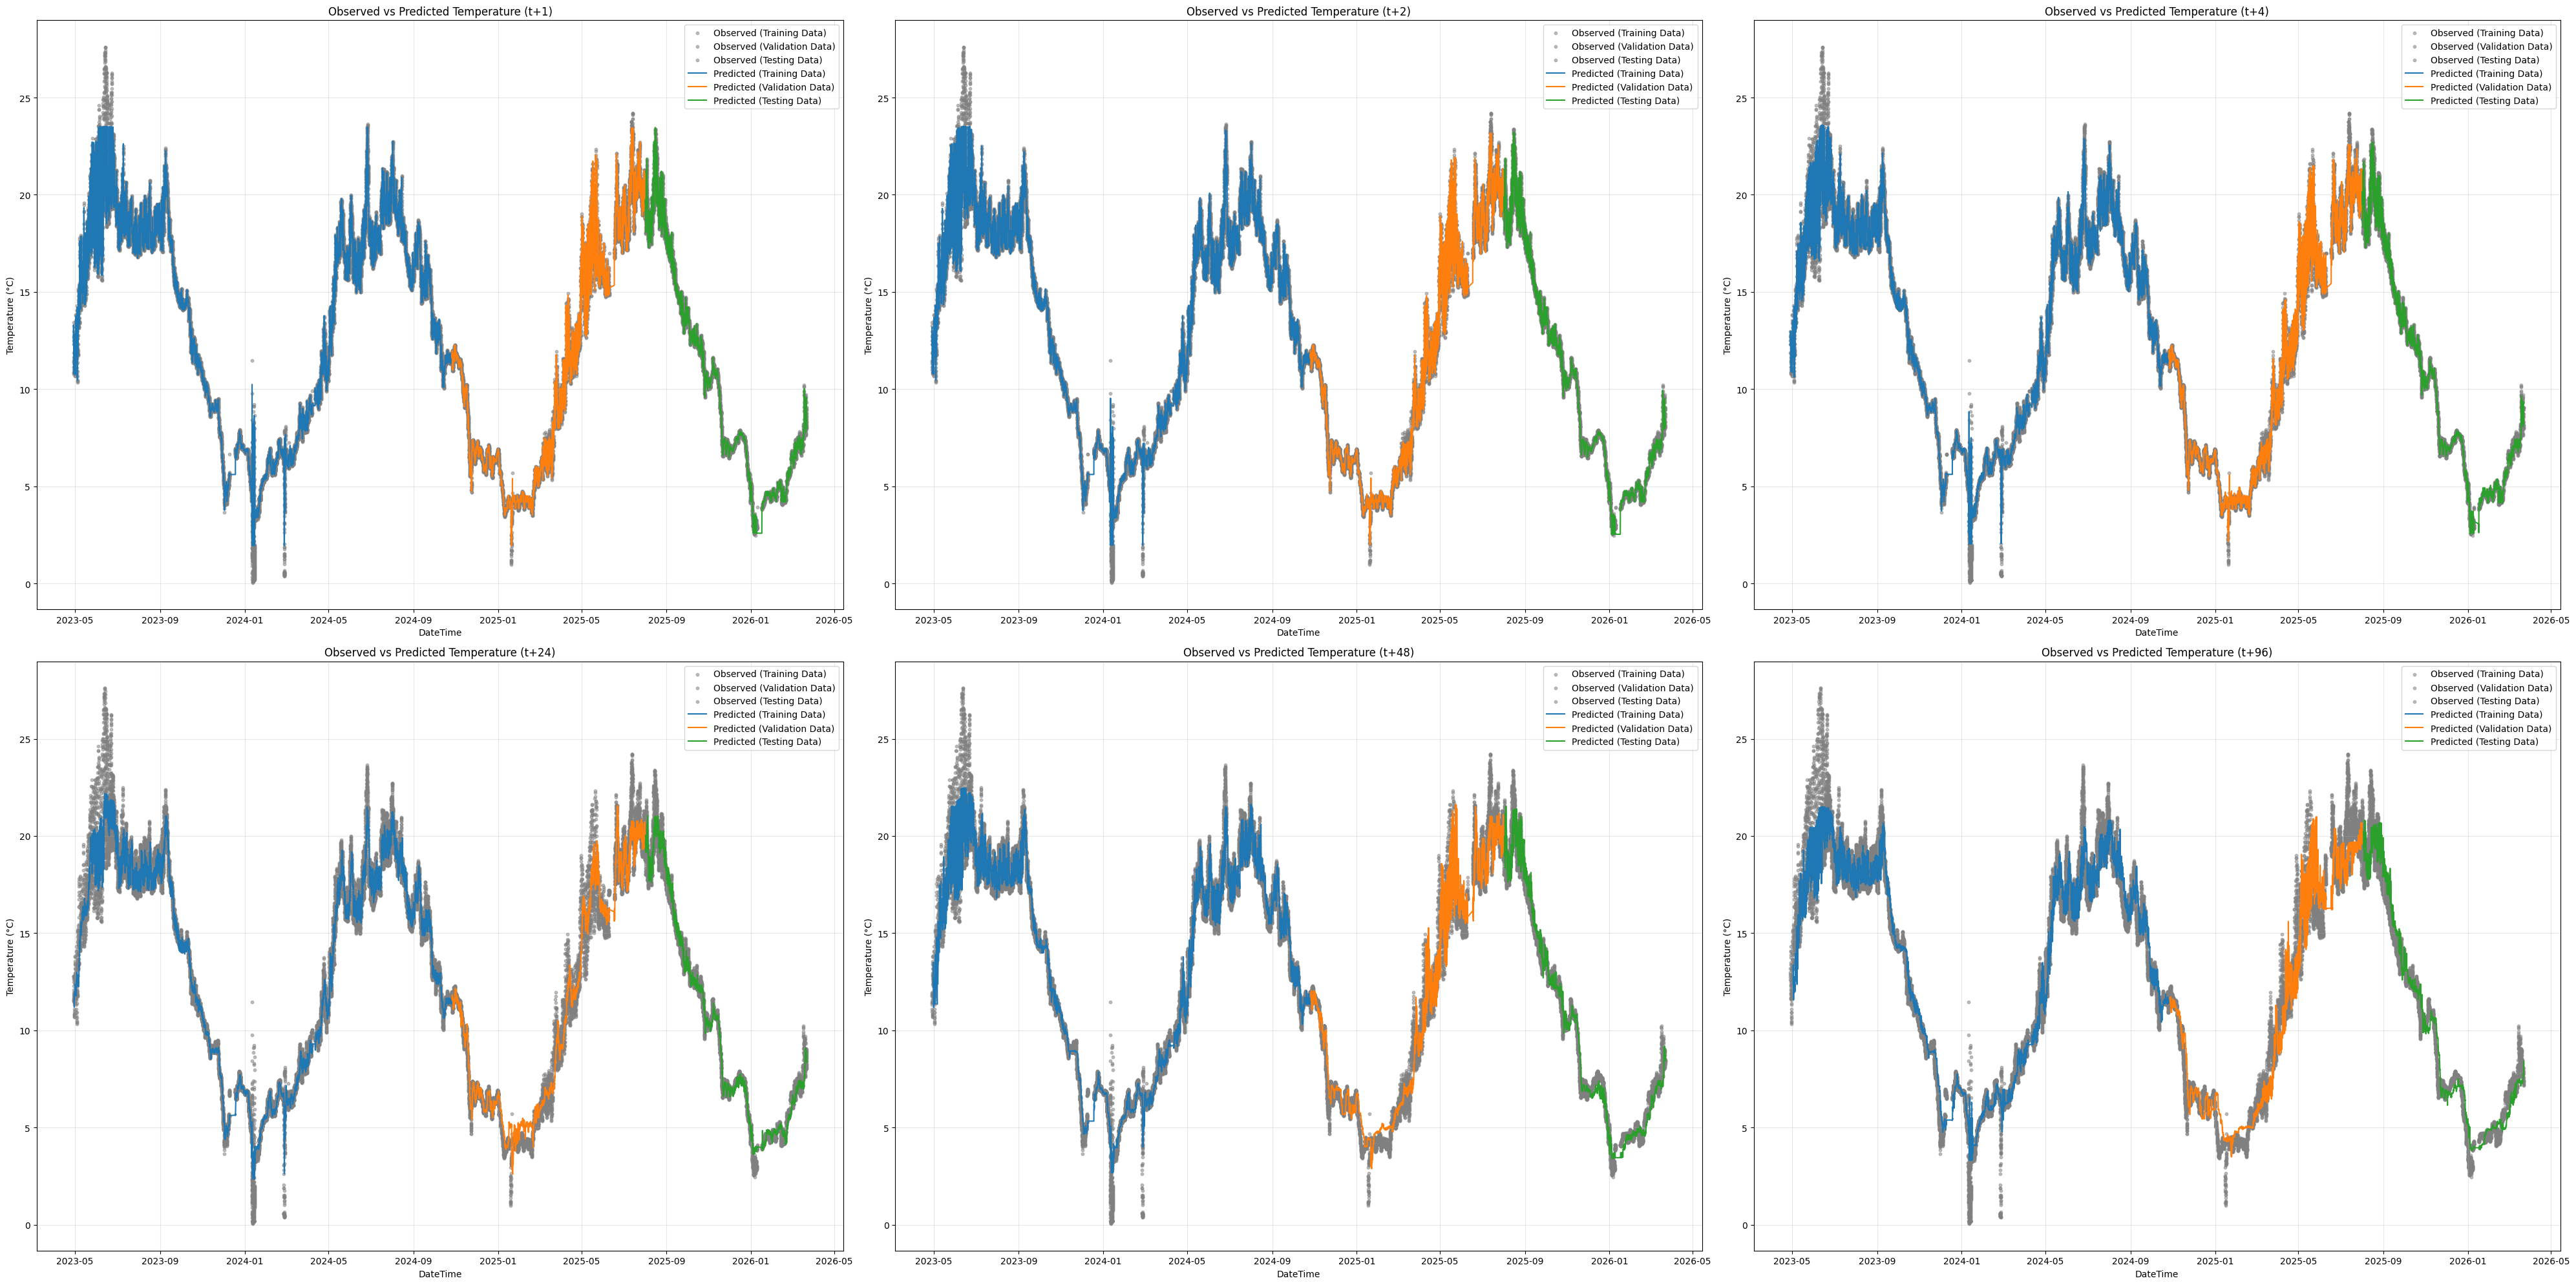

In [32]:
# Create a list of temperature targets
temperature_targets = targets[-int(len(targets)/3):]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(temperature_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through temperature targets for plotting
for i, target in enumerate(temperature_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Temperature (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()